# Cyclical Patterns — Daily & Weekly Profiles

This notebook examines the **intra-day** (hour-of-day) and **intra-week** (day-of-week) cycles embedded in each variable.
By placing all profiles on comparable axes we can reason about how demand, PV, prices, and FCR-D revenues align — or clash — across these two timescales.

The key question: *when* does flexibility have the most value, and do the daily and weekly rhythms reinforce or counteract each other?

## 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import warnings, calendar
warnings.filterwarnings('ignore')

# Complementary palette (avoids thesis colours #FFCC00, #00BDF2, #F42CFF)
PAL = {
    'teal':   '#0D7C66',
    'coral':  '#E05D44',
    'slate':  '#4A6FA5',
    'plum':   '#8E5572',
    'amber':  '#D4A029',
    'stone':  '#6B7F82',
}
C = list(PAL.values())

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FAFAFA',
    'axes.edgecolor':    '#CCCCCC',
    'axes.grid':         True,
    'grid.color':        '#E5E5E5',
    'grid.linewidth':    0.6,
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif', 'Liberation Serif', 'Times New Roman', 'serif'],
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'figure.dpi':        130,
    'legend.framealpha':  0.85,
    'legend.edgecolor':  '#CCCCCC',
})

DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

def add_ci(ax, grouped, x, color, label=None, alpha_fill=0.15):
    mean = grouped.mean()
    q25  = grouped.quantile(0.25)
    q75  = grouped.quantile(0.75)
    ax.fill_between(x, q25, q75, alpha=alpha_fill, color=color, linewidth=0)
    ax.plot(x, mean, color=color, linewidth=2.2, label=label)

print("Setup complete \u2713")


Setup complete ✓


## 2 — Data loading & preparation

We load and process all datasets into aligned hourly series, then attach `hour` and `dow` columns for grouping.

In [2]:
# ── 2.1 Energy community ─────────────────────────────────
ec_raw = pd.read_csv('data_ec/s_data.csv')
ec_raw['reading_time'] = pd.to_datetime(ec_raw['reading_time'])
ec_raw = ec_raw.drop(columns=['Unnamed: 0'])

pv_raw   = ec_raw[ec_raw['Serial'] == -2].copy()
cons_raw = ec_raw[ec_raw['Serial'] != -2].copy()

def cumulative_to_hourly(df, value_col='Consumption'):
    records = []
    for serial, grp in df.groupby('Serial'):
        s = grp.set_index('reading_time')[value_col].sort_index()
        s = s[~s.index.duplicated(keep='first')]
        s = s.resample('h').mean().interpolate(method='linear')
        delta = s.diff().dropna().clip(lower=0)
        delta.name = 'kWh'
        records.append(delta.to_frame().assign(Serial=serial))
    return pd.concat(records)

cons_hourly = cumulative_to_hourly(cons_raw)
pv_hourly   = cumulative_to_hourly(pv_raw)

community_demand = cons_hourly.groupby(cons_hourly.index)['kWh'].sum().loc['2025']
community_pv     = pv_hourly.groupby(pv_hourly.index)['kWh'].sum().loc['2025']
net_load = (community_demand.reindex(community_pv.index) - community_pv).dropna()

print(f"Demand : {len(community_demand):,} h  |  PV : {len(community_pv):,} h  |  Net load : {len(net_load):,} h")


FileNotFoundError: [Errno 2] No such file or directory: 'data_ec/s_data.csv'

In [40]:
# ── 2.2 Spot prices ──────────────────────────────────────
spot_raw = pd.read_csv('data_spot/Elspotprices.csv', sep=';')
for col in ['SpotPriceDKK', 'SpotPriceEUR']:
    spot_raw[col] = spot_raw[col].str.replace(',', '.').astype(float)
spot_raw['HourDK'] = pd.to_datetime(spot_raw['HourDK'])
spot_dk2 = spot_raw[spot_raw['PriceArea'] == 'DK2'].set_index('HourDK').sort_index()

da_raw = pd.read_csv('data_spot/DayAheadPrices.csv', sep=';')
for col in ['DayAheadPriceEUR', 'DayAheadPriceDKK']:
    da_raw[col] = da_raw[col].str.replace(',', '.').astype(float)
da_raw['TimeDK'] = pd.to_datetime(da_raw['TimeDK'])
da_raw = da_raw.set_index('TimeDK').sort_index()
da_hourly = da_raw[['DayAheadPriceEUR', 'DayAheadPriceDKK']].resample('h').mean()
da_hourly = da_hourly.rename(columns={'DayAheadPriceDKK': 'SpotPriceDKK',
                                       'DayAheadPriceEUR': 'SpotPriceEUR'})
spot_full = pd.concat([
    spot_dk2[['SpotPriceDKK', 'SpotPriceEUR']],
    da_hourly[['SpotPriceDKK', 'SpotPriceEUR']]
]).sort_index()
spot_full = spot_full[~spot_full.index.duplicated(keep='first')].loc['2025']
print(f"Spot   : {len(spot_full):,} h")


Spot   : 8,759 h


In [41]:
# ── 2.3 FCR-D ────────────────────────────────────────────
fcrd_raw = pd.read_csv('data_FCRD/FcrNdDK2.csv', sep=';')
for col in ['PurchasedVolumeLocal', 'PurchasedVolumeTotal', 'PriceTotalEUR']:
    fcrd_raw[col] = fcrd_raw[col].str.replace(',', '.').astype(float)
fcrd_raw['HourDK'] = pd.to_datetime(fcrd_raw['HourDK'])
fcrd = fcrd_raw.set_index('HourDK').sort_index().loc['2025']
fcrd_auctions = fcrd[fcrd['AuctionType'] != 'Total'].copy()

# Pivot to get one price column per product x auction
fcrd_up_early = fcrd_auctions[(fcrd_auctions['ProductName']=='FCR-D upp') &
                              (fcrd_auctions['AuctionType']=='D-1 early')]['PriceTotalEUR']
fcrd_up_late  = fcrd_auctions[(fcrd_auctions['ProductName']=='FCR-D upp') &
                              (fcrd_auctions['AuctionType']=='D-1 late')]['PriceTotalEUR']
fcrd_dn_early = fcrd_auctions[(fcrd_auctions['ProductName']=='FCR-D ned') &
                              (fcrd_auctions['AuctionType']=='D-1 early')]['PriceTotalEUR']
fcrd_dn_late  = fcrd_auctions[(fcrd_auctions['ProductName']=='FCR-D ned') &
                              (fcrd_auctions['AuctionType']=='D-1 late')]['PriceTotalEUR']

print(f"FCR-D  : {len(fcrd_auctions):,} auction rows")


FCR-D  : 52,560 auction rows (prices in PriceTotalEUR)


In [42]:
# ── 2.4 Build master DataFrame ────────────────────────────
master = pd.DataFrame({
    'Demand (kWh/h)':    community_demand,
    'PV (kWh/h)':        community_pv,
    'Net load (kWh/h)':  net_load,
    'Spot (DKK/MWh)':    spot_full['SpotPriceDKK'],
}).dropna()

master['hour'] = master.index.hour
master['dow']  = master.index.dayofweek   # 0=Mon
master['weekday'] = master['dow'].map(lambda d: DOW_LABELS[d])

# FCR-D series get their own frames (different row count)
def prep_fcrd(series, name):
    df = series.to_frame(name)
    df['hour'] = df.index.hour
    df['dow']  = df.index.dayofweek
    return df

fcrd_frames = {
    'FCR-D\u2191 early': prep_fcrd(fcrd_up_early, 'price'),
    'FCR-D\u2191 late':  prep_fcrd(fcrd_up_late,  'price'),
    'FCR-D\u2193 early': prep_fcrd(fcrd_dn_early, 'price'),
    'FCR-D\u2193 late':  prep_fcrd(fcrd_dn_late,  'price'),
}

print(f"Master frame : {len(master):,} aligned hours")
print("Ready for cycle analysis \u2713")


Master frame : 8,757 aligned hours
Ready for cycle analysis ✓


---
## 3 — Daily cycle: average profile by hour of day

Each panel below shows the **mean** value for every hour (0–23), with the interquartile range shaded to convey variability.
All four variables are stacked vertically so you can read straight down a given hour and see how demand, PV, net load, and price relate.

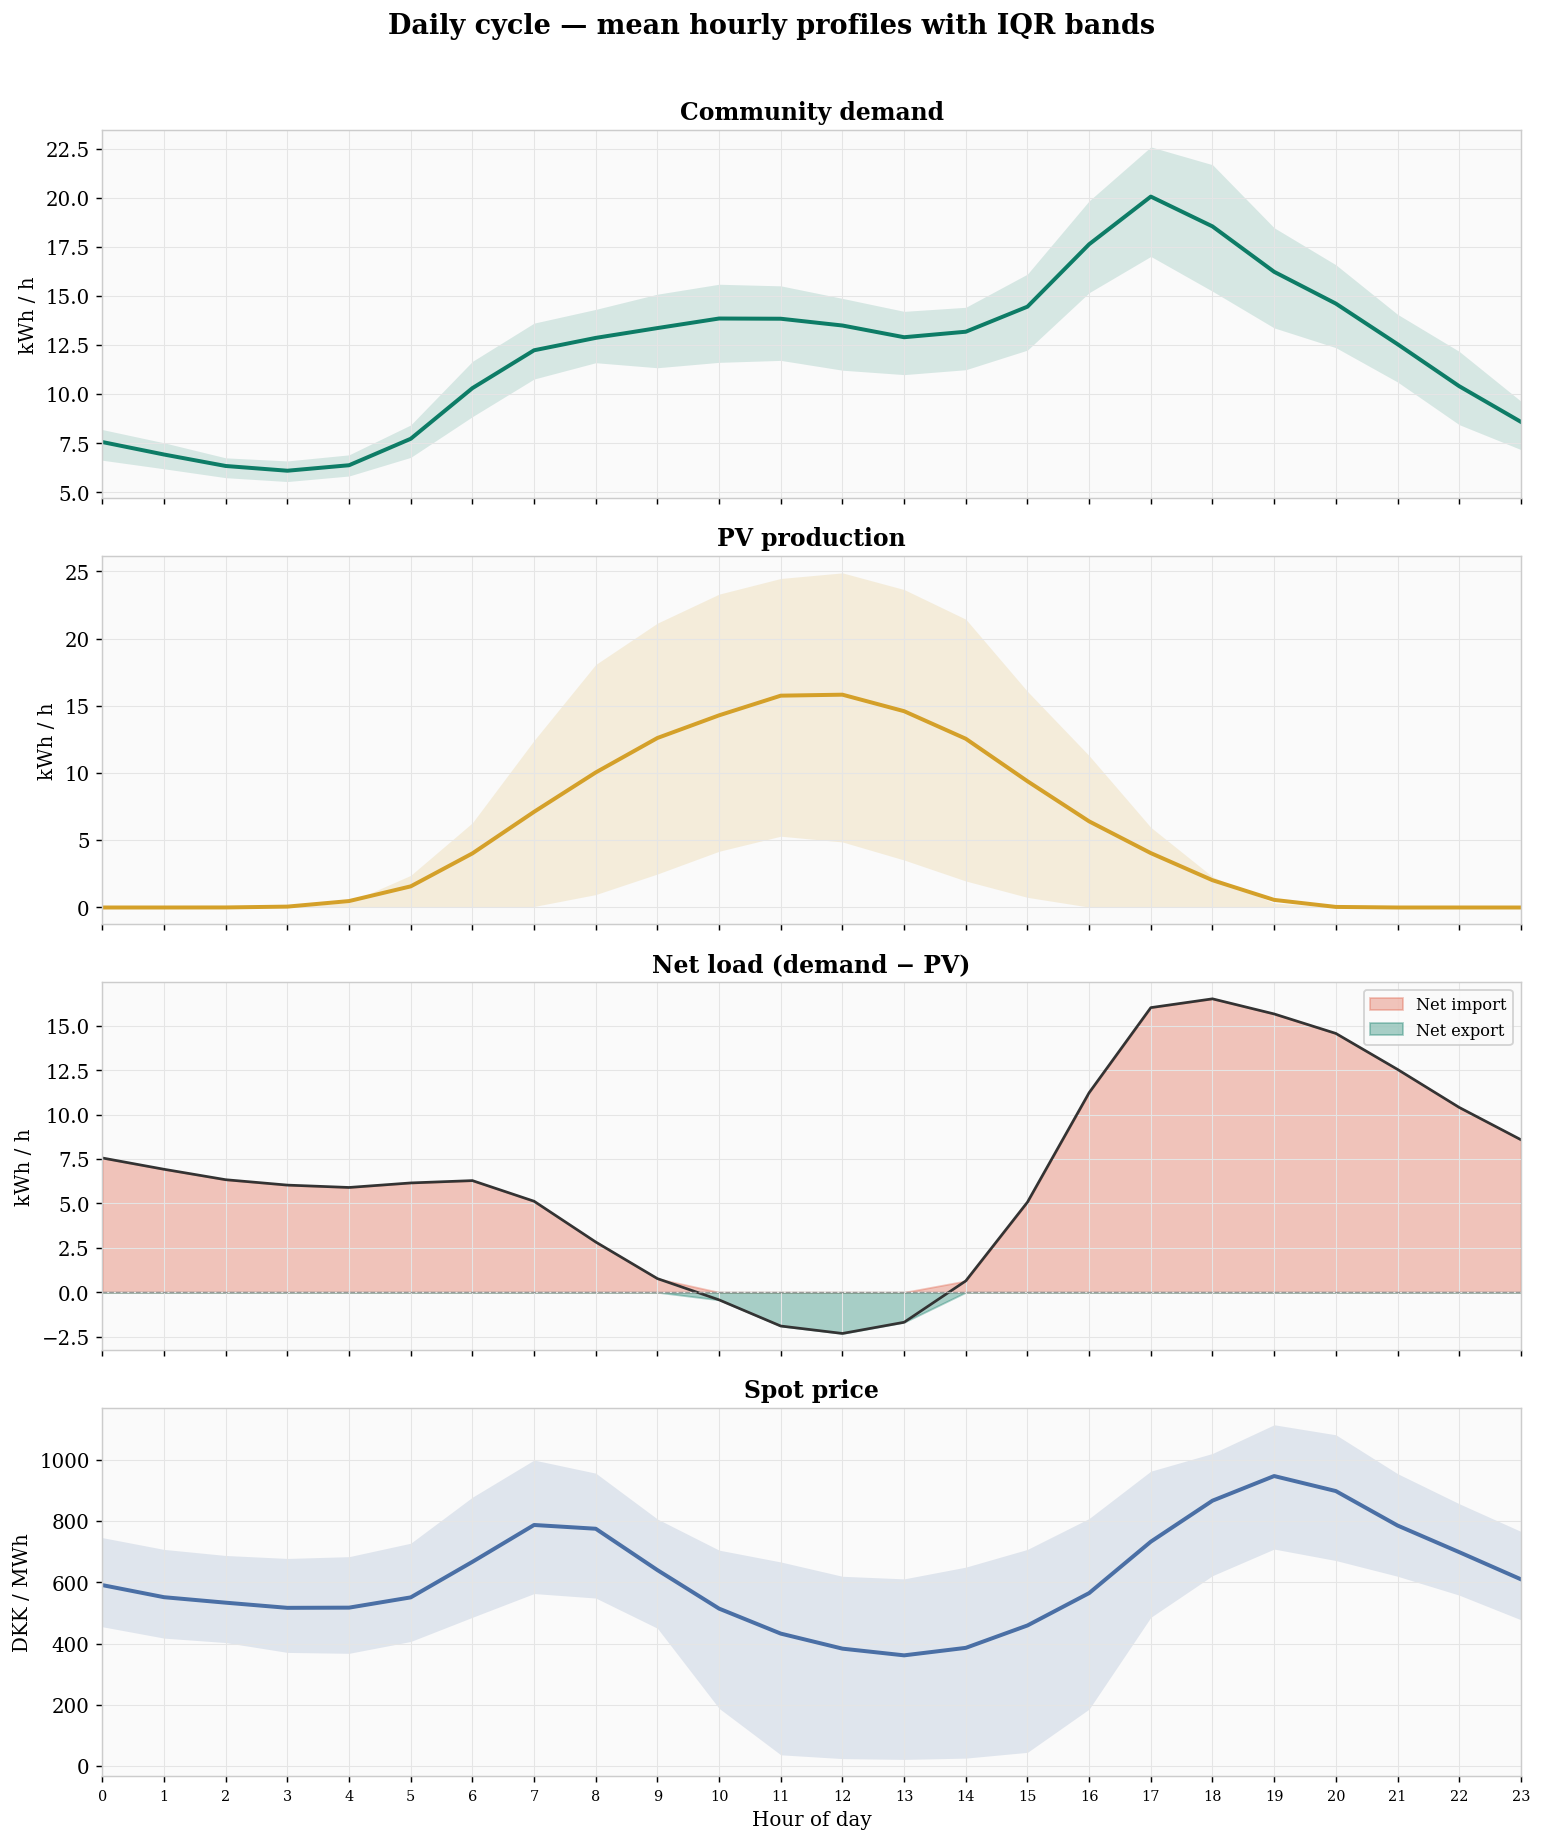

In [43]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
hours = range(24)

# Demand
g = master.groupby('hour')['Demand (kWh/h)']
add_ci(axes[0], g, hours, C[0], 'Demand')
axes[0].set_ylabel('kWh / h')
axes[0].set_title('Community demand')

# PV
g = master.groupby('hour')['PV (kWh/h)']
add_ci(axes[1], g, hours, C[4], 'PV production')
axes[1].set_ylabel('kWh / h')
axes[1].set_title('PV production')

# Net load
g = master.groupby('hour')['Net load (kWh/h)']
mean_net = g.mean()
axes[2].fill_between(hours, 0, mean_net.clip(lower=0), alpha=0.35, color=C[1], label='Net import')
axes[2].fill_between(hours, 0, mean_net.clip(upper=0), alpha=0.35, color=C[0], label='Net export')
axes[2].plot(hours, mean_net, color='#333', linewidth=1.5)
axes[2].axhline(0, color='#999', linewidth=0.7, linestyle='--')
axes[2].set_ylabel('kWh / h')
axes[2].set_title('Net load (demand \u2212 PV)')
axes[2].legend(fontsize=9)

# Spot price
g = master.groupby('hour')['Spot (DKK/MWh)']
add_ci(axes[3], g, hours, C[2], 'Spot price')
axes[3].set_ylabel('DKK / MWh')
axes[3].set_title('Spot price')
axes[3].set_xlabel('Hour of day')

for ax in axes:
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 1))
    ax.set_xticklabels([str(h) for h in range(24)], fontsize=8)

fig.suptitle('Daily cycle — mean hourly profiles with IQR bands',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


### 3.1 — FCR-D daily profiles

FCR-D prices have their own rhythm. Up-regulation and down-regulation are shown separately, each split by early and late auction.

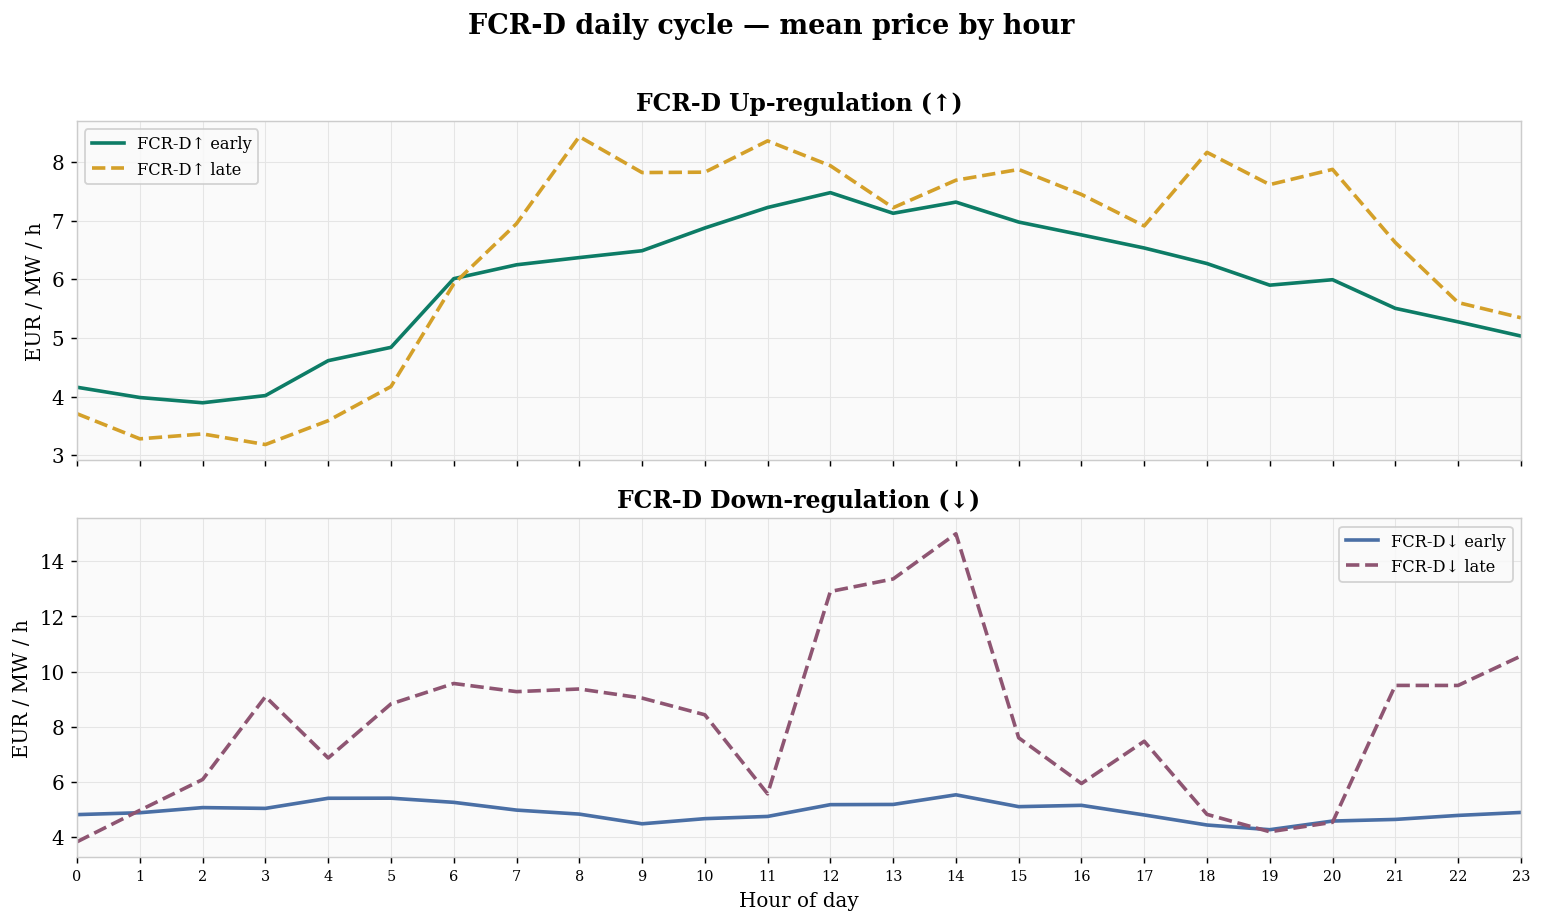

In [44]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
hours = range(24)

fcrd_colors = {
    'FCR-D\u2191 early': C[0],
    'FCR-D\u2191 late':  C[4],
    'FCR-D\u2193 early': C[2],
    'FCR-D\u2193 late':  C[3],
}
fcrd_ls = {
    'FCR-D\u2191 early': '-',  'FCR-D\u2191 late': '--',
    'FCR-D\u2193 early': '-',  'FCR-D\u2193 late': '--',
}

for label, df in fcrd_frames.items():
    if '\u2191' in label:
        ax = axes[0]
    else:
        ax = axes[1]
    profile = df.groupby('hour')['price'].mean()
    ax.plot(profile.index, profile.values, color=fcrd_colors[label],
            linewidth=2, linestyle=fcrd_ls[label], label=label)

axes[0].set_ylabel('EUR / MW / h')
axes[0].set_title('FCR-D Up-regulation (\u2191)')
axes[0].legend(fontsize=9)
axes[1].set_ylabel('EUR / MW / h')
axes[1].set_title('FCR-D Down-regulation (\u2193)')
axes[1].legend(fontsize=9)
axes[1].set_xlabel('Hour of day')

for ax in axes:
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 1))
    ax.set_xticklabels([str(h) for h in range(24)], fontsize=8)

fig.suptitle('FCR-D daily cycle — mean price by hour', fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


### 3.2 — All variables on one normalised daily axis

To compare shapes directly, each variable is **min-max normalised** to [0, 1]. This strips away the units and lets us see which peaks and troughs coincide.

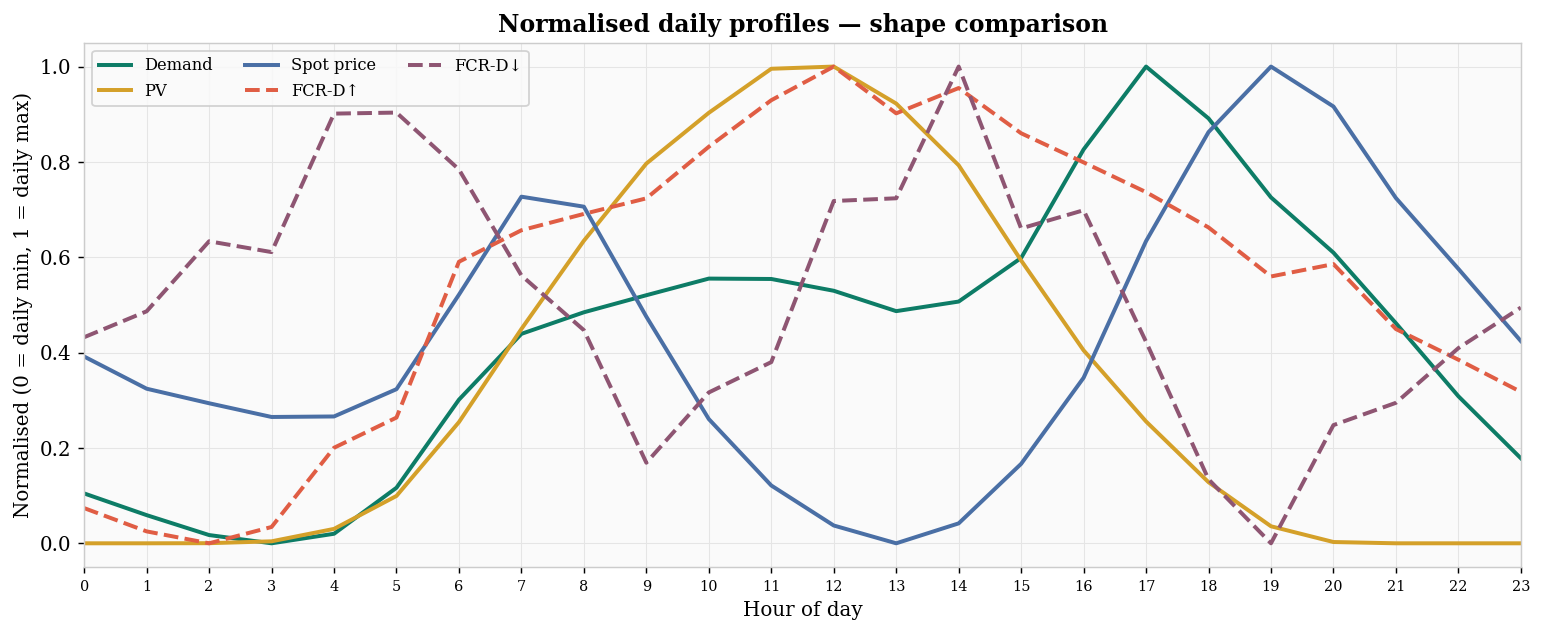

In [45]:
fig, ax = plt.subplots(figsize=(12, 5))
hours = range(24)

def norm01(s):
    return (s - s.min()) / (s.max() - s.min())

series_daily = {
    'Demand':       (master.groupby('hour')['Demand (kWh/h)'].mean(),   C[0], '-'),
    'PV':           (master.groupby('hour')['PV (kWh/h)'].mean(),       C[4], '-'),
    'Spot price':   (master.groupby('hour')['Spot (DKK/MWh)'].mean(),   C[2], '-'),
    'FCR-D\u2191': (fcrd_frames['FCR-D\u2191 early'].groupby('hour')['price'].mean(), C[1], '--'),
    'FCR-D\u2193': (fcrd_frames['FCR-D\u2193 early'].groupby('hour')['price'].mean(), C[3], '--'),
}

for label, (s, col, ls) in series_daily.items():
    ax.plot(hours, norm01(s), color=col, linewidth=2.2, linestyle=ls, label=label)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Normalised (0 = daily min, 1 = daily max)')
ax.set_title('Normalised daily profiles — shape comparison', fontweight='bold')
ax.set_xlim(0, 23)
ax.set_xticks(range(0, 24, 1))
ax.set_xticklabels([str(h) for h in range(24)], fontsize=8)
ax.legend(fontsize=9, ncol=3, loc='upper left')
fig.tight_layout()
plt.show()


---
## 4 — Weekly cycle: average profile by day of week

Now we aggregate to the daily level and group by day of week (Monday–Sunday) to reveal the weekly rhythm.

In [46]:
# Compute daily totals / means
daily = master.resample('D').agg({
    'Demand (kWh/h)': 'sum',     # total daily kWh
    'PV (kWh/h)':     'sum',
    'Net load (kWh/h)': 'sum',
    'Spot (DKK/MWh)': 'mean',    # average price that day
})
daily.columns = ['Demand (kWh/day)', 'PV (kWh/day)', 'Net load (kWh/day)', 'Spot mean (DKK/MWh)']
daily['dow'] = daily.index.dayofweek

print("Daily aggregation ready \u2713")
print(daily.head(3))


Daily aggregation ready ✓
            Demand (kWh/day)  PV (kWh/day)  Net load (kWh/day)  \
2025-01-01            325.15          1.69              323.46   
2025-01-02            296.40          0.58              295.82   
2025-01-03            317.75          0.45              317.30   

            Spot mean (DKK/MWh)  dow  
2025-01-01            48.030869    2  
2025-01-02           609.013336    3  
2025-01-03           482.215832    4  


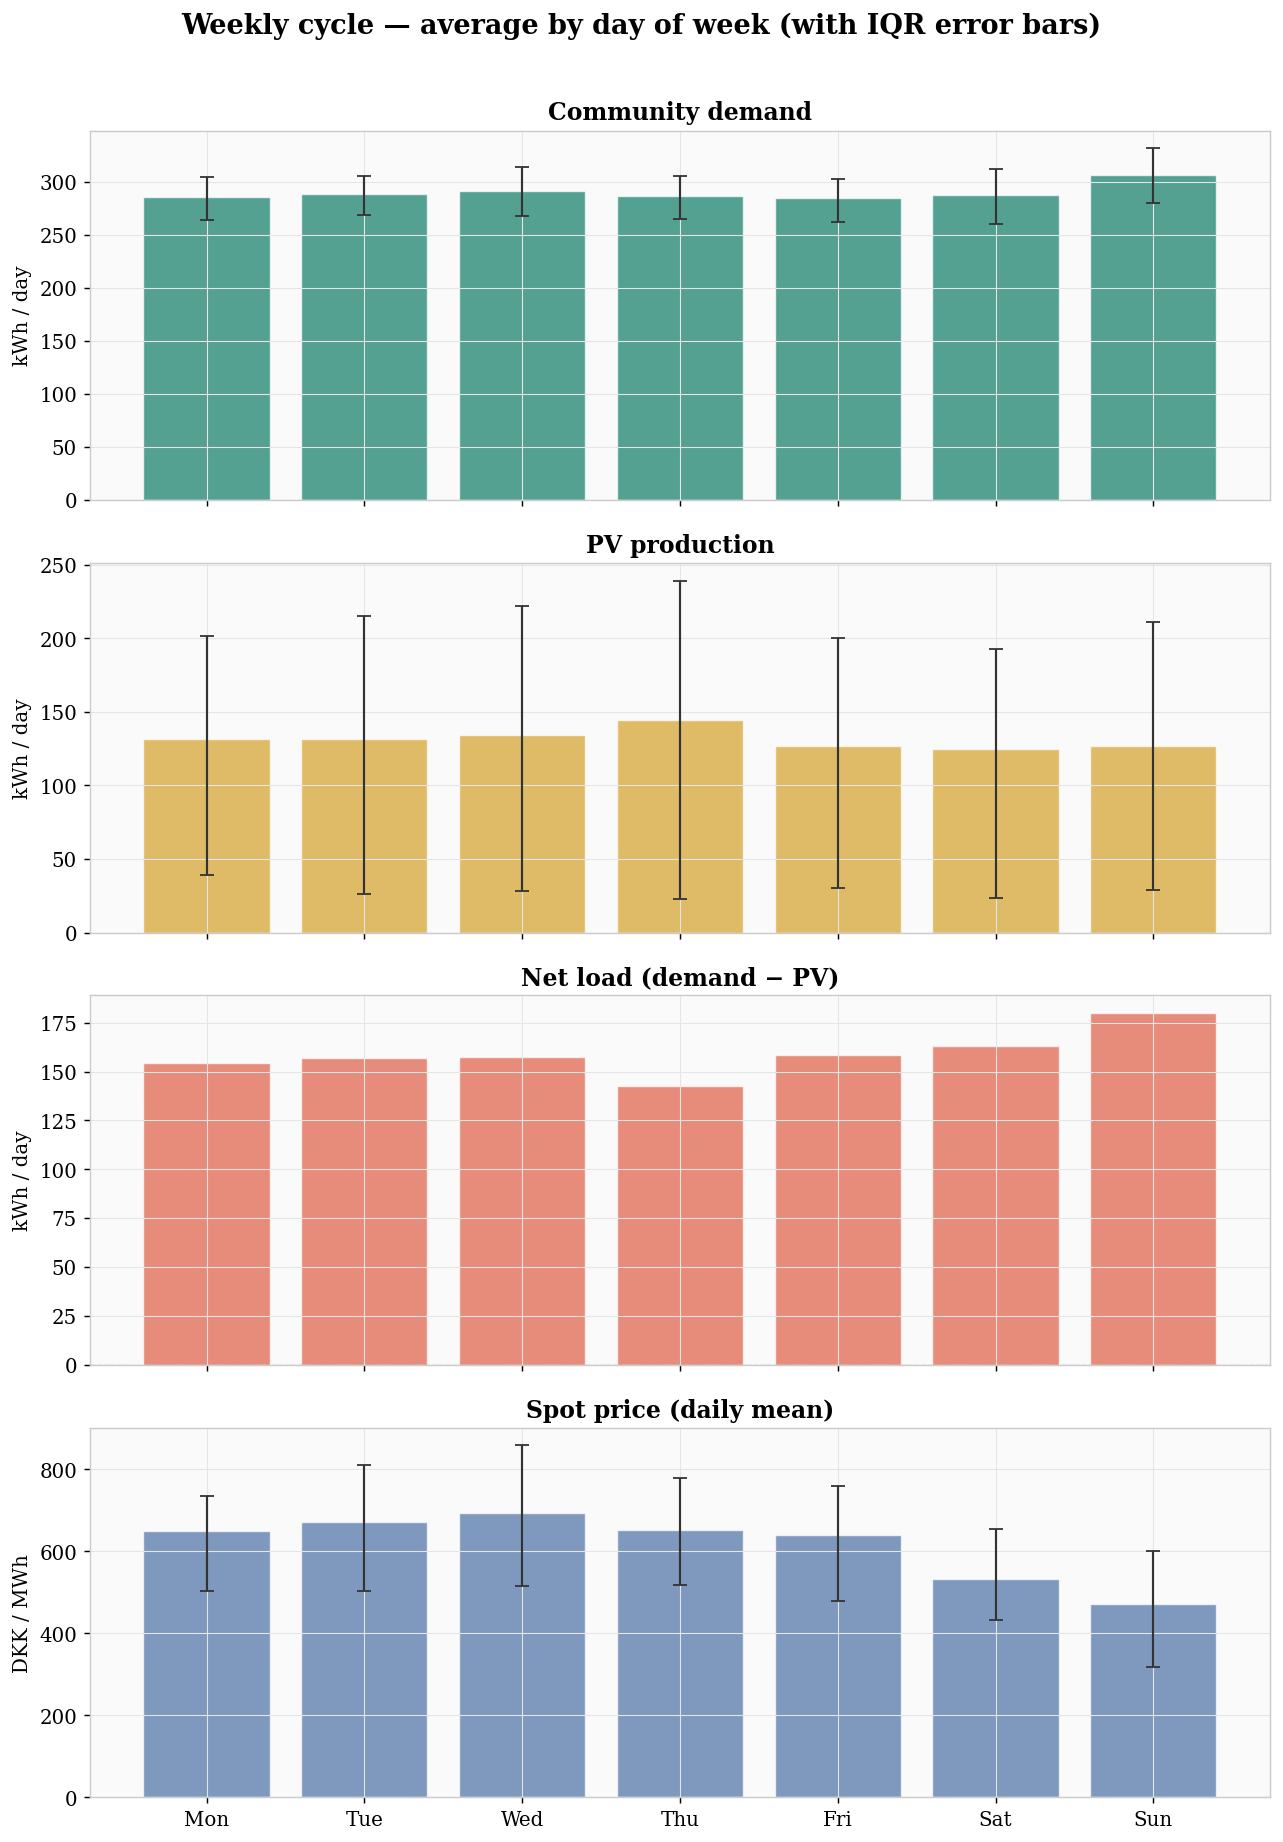

In [47]:
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)
x = range(7)

# Demand
g = daily.groupby('dow')['Demand (kWh/day)']
mean_vals = g.mean()
q25 = g.quantile(0.25)
q75 = g.quantile(0.75)
axes[0].bar(x, mean_vals, color=C[0], alpha=0.7, edgecolor='white', linewidth=0.8)
axes[0].errorbar(x, mean_vals, yerr=[mean_vals - q25, q75 - mean_vals],
                 fmt='none', color='#333', capsize=4, linewidth=1.2)
axes[0].set_ylabel('kWh / day')
axes[0].set_title('Community demand')

# PV
g = daily.groupby('dow')['PV (kWh/day)']
mean_vals = g.mean()
q25 = g.quantile(0.25)
q75 = g.quantile(0.75)
axes[1].bar(x, mean_vals, color=C[4], alpha=0.7, edgecolor='white', linewidth=0.8)
axes[1].errorbar(x, mean_vals, yerr=[mean_vals - q25, q75 - mean_vals],
                 fmt='none', color='#333', capsize=4, linewidth=1.2)
axes[1].set_ylabel('kWh / day')
axes[1].set_title('PV production')

# Net load
g = daily.groupby('dow')['Net load (kWh/day)']
mean_vals = g.mean()
colors_bar = [C[1] if v >= 0 else C[0] for v in mean_vals]
axes[2].bar(x, mean_vals, color=colors_bar, alpha=0.7, edgecolor='white', linewidth=0.8)
axes[2].axhline(0, color='#999', linewidth=0.7, linestyle='--')
axes[2].set_ylabel('kWh / day')
axes[2].set_title('Net load (demand \u2212 PV)')

# Spot
g = daily.groupby('dow')['Spot mean (DKK/MWh)']
mean_vals = g.mean()
q25 = g.quantile(0.25)
q75 = g.quantile(0.75)
axes[3].bar(x, mean_vals, color=C[2], alpha=0.7, edgecolor='white', linewidth=0.8)
axes[3].errorbar(x, mean_vals, yerr=[mean_vals - q25, q75 - mean_vals],
                 fmt='none', color='#333', capsize=4, linewidth=1.2)
axes[3].set_ylabel('DKK / MWh')
axes[3].set_title('Spot price (daily mean)')

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(DOW_LABELS)

fig.suptitle('Weekly cycle — average by day of week (with IQR error bars)',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


### 4.1 — FCR-D weekly profiles

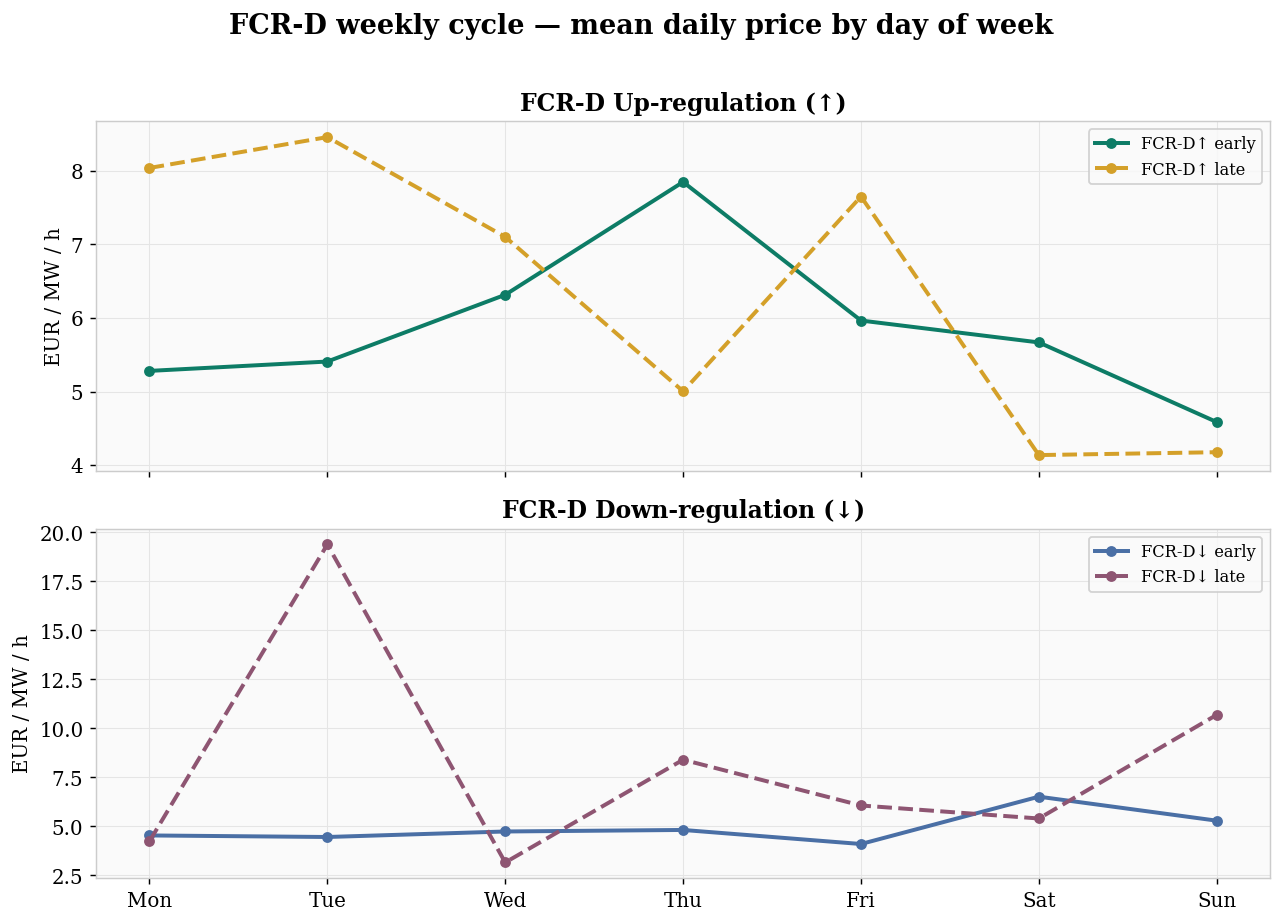

In [48]:
# Daily mean FCR-D prices
fcrd_daily = {}
for label, df in fcrd_frames.items():
    daily_p = df.resample('D')['price'].mean()
    daily_p = daily_p.to_frame('price')
    daily_p['dow'] = daily_p.index.dayofweek
    fcrd_daily[label] = daily_p

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
x = range(7)

for label, df in fcrd_daily.items():
    if '\u2191' in label:
        ax = axes[0]
    else:
        ax = axes[1]
    g = df.groupby('dow')['price']
    mean_vals = g.mean()
    col = fcrd_colors[label]
    ls = fcrd_ls[label]
    ax.plot(x, mean_vals, color=col, linewidth=2.2, linestyle=ls, label=label, marker='o', markersize=5)

axes[0].set_ylabel('EUR / MW / h')
axes[0].set_title('FCR-D Up-regulation (\u2191)')
axes[0].legend(fontsize=9)
axes[1].set_ylabel('EUR / MW / h')
axes[1].set_title('FCR-D Down-regulation (\u2193)')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(DOW_LABELS)

fig.suptitle('FCR-D weekly cycle — mean daily price by day of week',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


### 4.2 — All variables on one normalised weekly axis

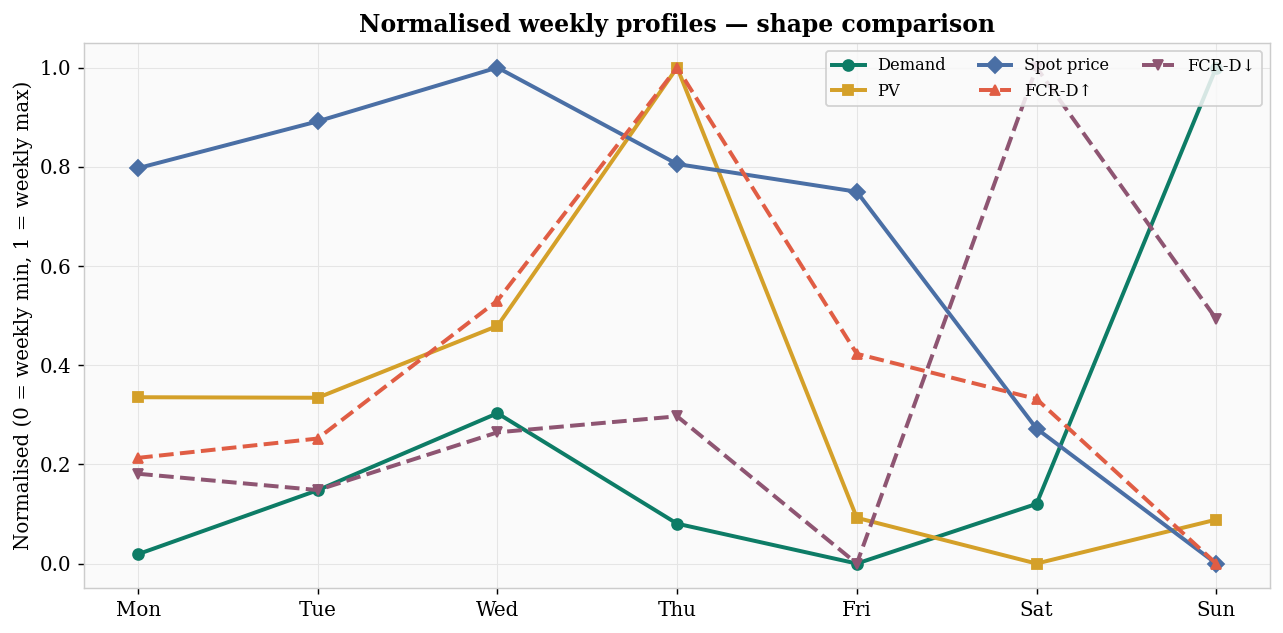

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(7)

series_weekly = {
    'Demand':       (daily.groupby('dow')['Demand (kWh/day)'].mean(),   C[0], '-',  'o'),
    'PV':           (daily.groupby('dow')['PV (kWh/day)'].mean(),       C[4], '-',  's'),
    'Spot price':   (daily.groupby('dow')['Spot mean (DKK/MWh)'].mean(), C[2], '-', 'D'),
    'FCR-D\u2191': (fcrd_daily['FCR-D\u2191 early'].groupby('dow')['price'].mean(), C[1], '--', '^'),
    'FCR-D\u2193': (fcrd_daily['FCR-D\u2193 early'].groupby('dow')['price'].mean(), C[3], '--', 'v'),
}

for label, (s, col, ls, marker) in series_weekly.items():
    ax.plot(x, norm01(s), color=col, linewidth=2.2, linestyle=ls,
            marker=marker, markersize=6, label=label)

ax.set_xticks(x)
ax.set_xticklabels(DOW_LABELS)
ax.set_ylabel('Normalised (0 = weekly min, 1 = weekly max)')
ax.set_title('Normalised weekly profiles — shape comparison', fontweight='bold')
ax.legend(fontsize=9, ncol=3, loc='upper right')
fig.tight_layout()
plt.show()


---
## 5 — Weekday vs. weekend daily profiles

The daily cycle itself shifts between workdays and weekends. We overlay the two to quantify the difference — critical for scheduling strategies that must adapt to the weekly rhythm.

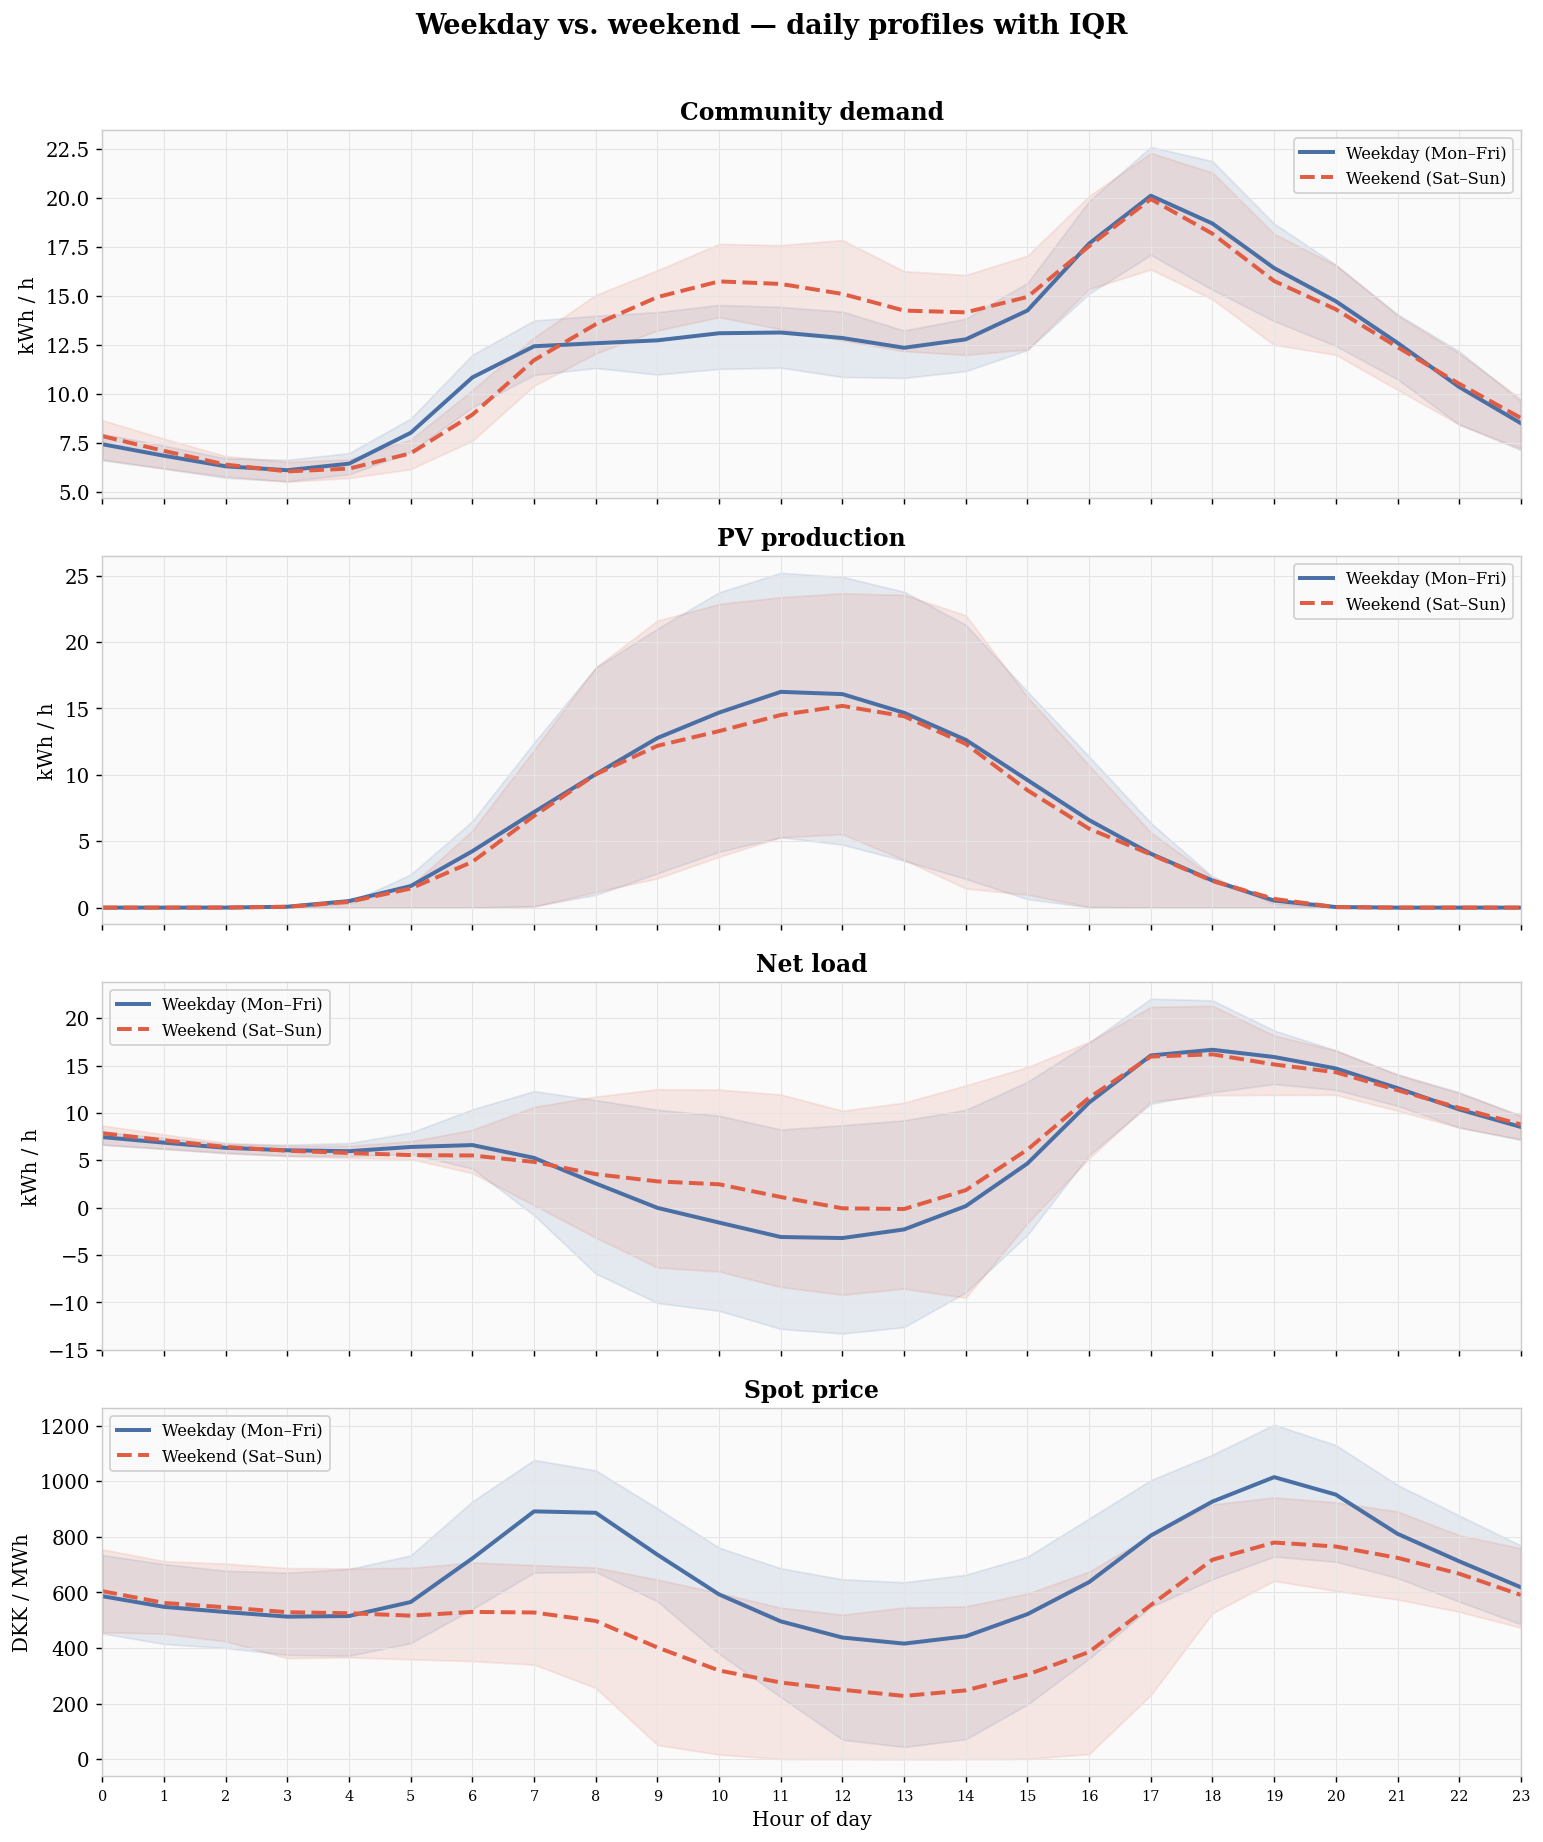

In [50]:
master['is_weekend'] = master['dow'] >= 5

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
hours = range(24)

variables = [
    ('Demand (kWh/h)', 'Community demand',  'kWh / h'),
    ('PV (kWh/h)',     'PV production',     'kWh / h'),
    ('Net load (kWh/h)', 'Net load',        'kWh / h'),
    ('Spot (DKK/MWh)', 'Spot price',        'DKK / MWh'),
]

for ax, (col, title, ylabel) in zip(axes, variables):
    wd = master[~master['is_weekend']].groupby('hour')[col]
    we = master[ master['is_weekend']].groupby('hour')[col]

    ax.fill_between(hours, wd.quantile(0.25), wd.quantile(0.75),
                    alpha=0.12, color=C[2])
    ax.plot(hours, wd.mean(), color=C[2], linewidth=2.2, label='Weekday (Mon\u2013Fri)')

    ax.fill_between(hours, we.quantile(0.25), we.quantile(0.75),
                    alpha=0.12, color=C[1])
    ax.plot(hours, we.mean(), color=C[1], linewidth=2.2, linestyle='--', label='Weekend (Sat\u2013Sun)')

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Hour of day')
for ax in axes:
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 1))
    ax.set_xticklabels([str(h) for h in range(24)], fontsize=8)

fig.suptitle('Weekday vs. weekend — daily profiles with IQR',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


### 5.1 — Weekday vs. weekend FCR-D

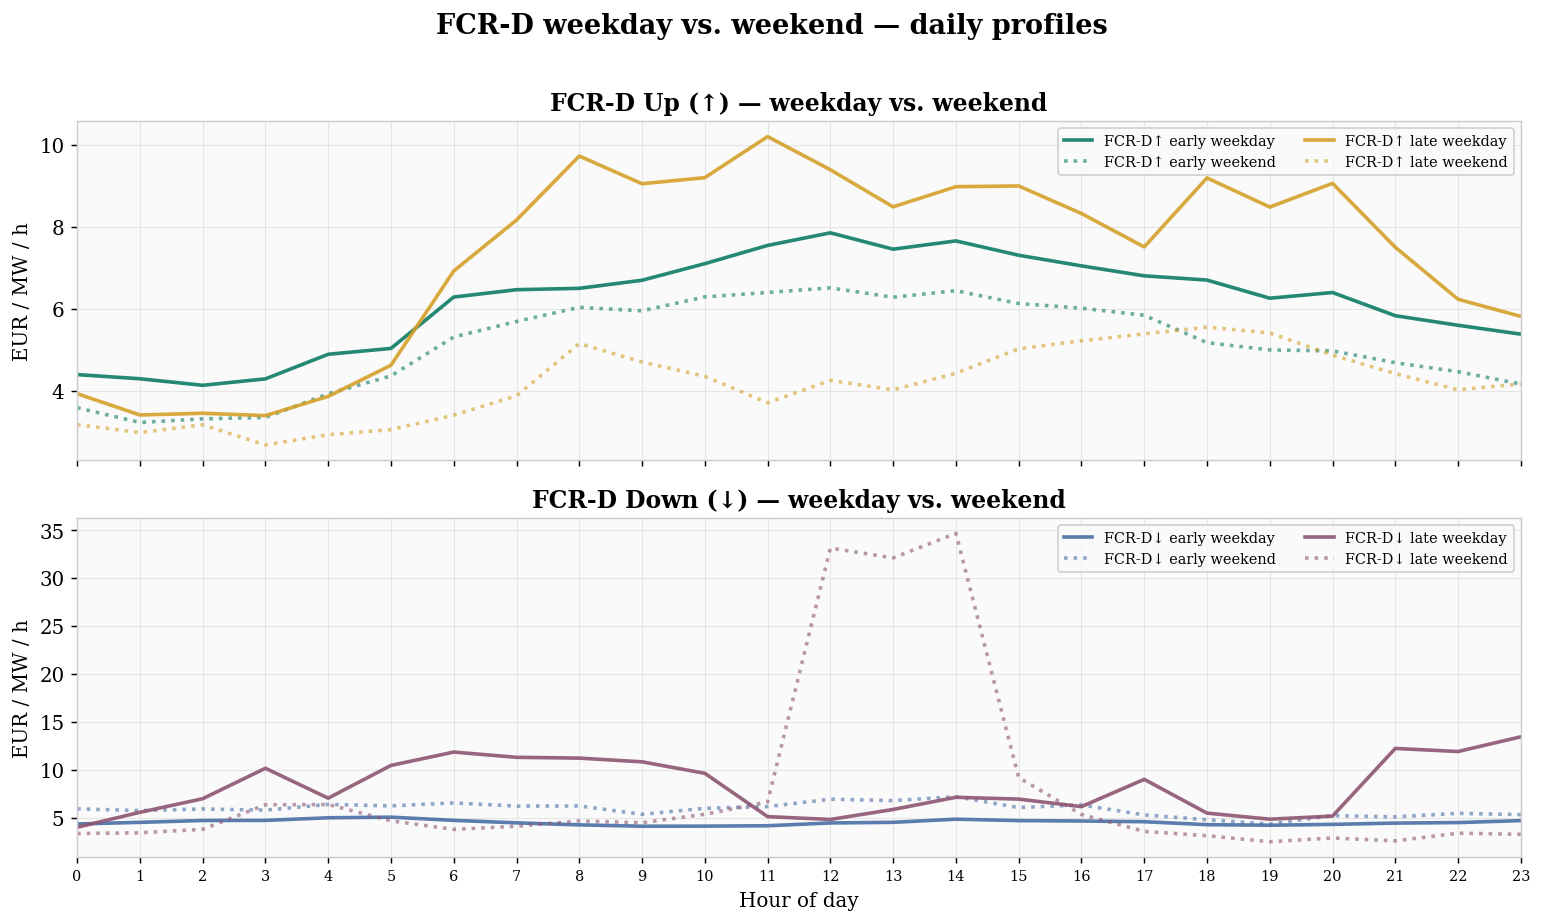

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
hours = range(24)

for label, df in fcrd_frames.items():
    if '\u2191' in label:
        ax = axes[0]
    else:
        ax = axes[1]

    df['is_weekend'] = df['dow'] >= 5
    ls_base = fcrd_ls[label]
    col = fcrd_colors[label]

    wd_mean = df[~df['is_weekend']].groupby('hour')['price'].mean()
    we_mean = df[ df['is_weekend']].groupby('hour')['price'].mean()

    lbl_wd = label + ' weekday'
    lbl_we = label + ' weekend'
    ax.plot(hours, wd_mean, color=col, linewidth=2, linestyle='-', alpha=0.9, label=lbl_wd)
    ax.plot(hours, we_mean, color=col, linewidth=2, linestyle=':', alpha=0.6, label=lbl_we)

axes[0].set_ylabel('EUR / MW / h')
axes[0].set_title('FCR-D Up (\u2191) — weekday vs. weekend')
axes[0].legend(fontsize=8, ncol=2)
axes[1].set_ylabel('EUR / MW / h')
axes[1].set_title('FCR-D Down (\u2193) — weekday vs. weekend')
axes[1].legend(fontsize=8, ncol=2)

for ax in axes:
    ax.set_xlim(0, 23)
    ax.set_xticks(range(0, 24, 1))
    ax.set_xticklabels([str(h) for h in range(24)], fontsize=8)
axes[1].set_xlabel('Hour of day')

fig.suptitle('FCR-D weekday vs. weekend — daily profiles',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


---
## 6 — Combined view: hour-of-week heatmaps

These heatmaps show the interaction of both cycles at once — each cell is the average value for a specific (day-of-week, hour-of-day) combination. This is the most compact way to see the full weekly pattern.

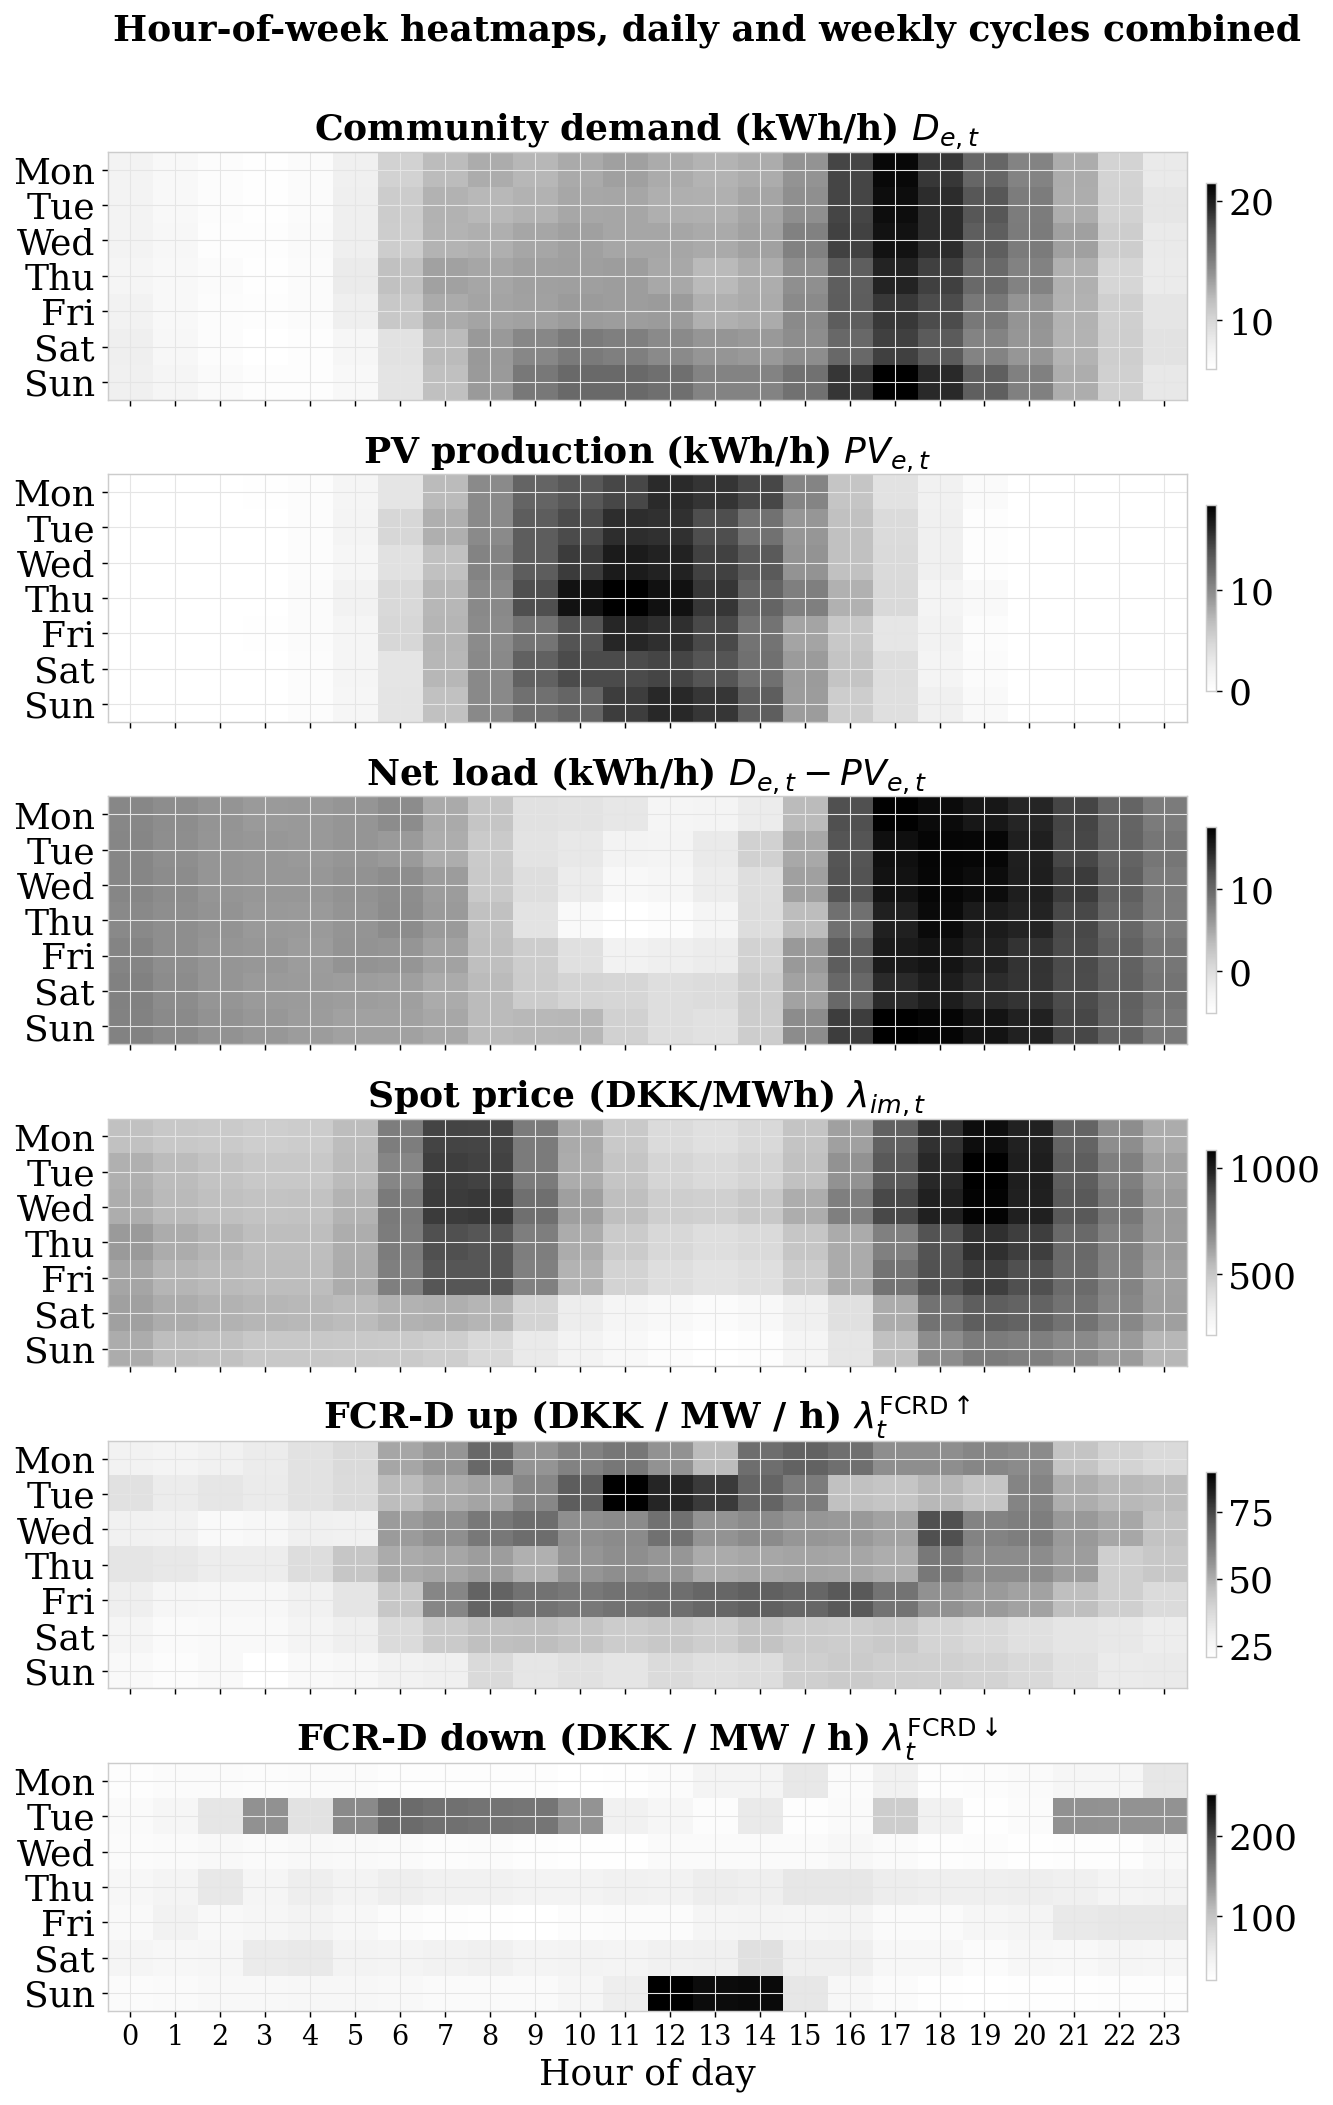

In [89]:
fig, axes = plt.subplots(6, 1, figsize=(11, 16), sharex=True)

cmaps = ['Greys'] * 6

variables_hm = [
    ('Demand (kWh/h)', 'Community demand (kWh/h)', r'$D_{e,t}$'),
    ('PV (kWh/h)',     'PV production (kWh/h)', r'$PV_{e,t}$'),
    ('Net load (kWh/h)', 'Net load (kWh/h)', r'$D_{e,t} - PV_{e,t}$'),
    ('Spot (DKK/MWh)', 'Spot price (DKK/MWh)', r'$\lambda_{im,t}$'),
    ('FCR-D up (DKK/MW/h)', 'FCR-D up (DKK / MW / h)', r'$\lambda^{\mathrm{FCRD}\uparrow}_{t}$'),
    ('FCR-D down (DKK/MW/h)', 'FCR-D down (DKK / MW / h)', r'$\lambda^{\mathrm{FCRD}\downarrow}_{t}$'),
]

# Prepare combined FCR-D up/down frames (merge early & late auctions)
# Some auction hours may be missing; dropna before grouping
# Convert prices from EUR to DKK (approximately 7.45 DKK/EUR)
eur_to_dkk = 7.45

fcrd_up = pd.concat([
    fcrd_frames['FCR-D\u2191 early']['price'],
    fcrd_frames['FCR-D\u2191 late']['price']
]).dropna()
fcrd_up = fcrd_up.to_frame('price')
fcrd_up['price'] = fcrd_up['price'] * eur_to_dkk  # Convert to DKK
fcrd_up['hour'] = fcrd_up.index.hour
fcrd_up['dow'] = fcrd_up.index.dayofweek

fcrd_down = pd.concat([
    fcrd_frames['FCR-D\u2193 early']['price'],
    fcrd_frames['FCR-D\u2193 late']['price']
]).dropna()
fcrd_down = fcrd_down.to_frame('price')
fcrd_down['price'] = fcrd_down['price'] * eur_to_dkk  # Convert to DKK
fcrd_down['hour'] = fcrd_down.index.hour
fcrd_down['dow'] = fcrd_down.index.dayofweek

FONTSIZE1 = 20
FONTSIZE2 = 45


for ax, cmap, (col, title, symbol) in zip(axes, cmaps, variables_hm):
    if col in master.columns:
        pivot = master.groupby(['dow', 'hour'])[col].mean().unstack('hour')
    elif 'FCR-D up' in col:
        pivot = fcrd_up.groupby(['dow', 'hour'])['price'].mean().unstack('hour')
    elif 'FCR-D down' in col:
        pivot = fcrd_down.groupby(['dow', 'hour'])['price'].mean().unstack('hour')
    else:
        pivot = pd.DataFrame(index=range(7), columns=range(24)).fillna(np.nan)

    # Ensure index labels are the day names
    pivot.index = DOW_LABELS
    im = ax.imshow(pivot.values, aspect='auto', cmap=cmap, interpolation='nearest')
    ax.set_yticks(range(7))
    ax.set_yticklabels(DOW_LABELS, fontsize=FONTSIZE1)
    ax.set_title(f"{title} {symbol}", fontsize=FONTSIZE1, fontweight='bold')
    cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.015)
    cbar.ax.tick_params(labelsize=FONTSIZE1, colors='black')

axes[-1].set_xticks(range(24))
axes[-1].set_xticklabels([str(h) for h in range(24)], fontsize=15)
axes[-1].set_xlabel('Hour of day', fontsize=FONTSIZE1)


fig.suptitle('Hour-of-week heatmaps, daily and weekly cycles combined',
             fontsize=FONTSIZE1, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

---
## 7 — Quantitative summary of cyclical variation

How much does each variable swing within a day and within a week? The table below reports the ratio of peak-to-trough for each cycle — a ratio of 2.0 means the peak is twice the trough.

In [53]:
daily_col_map = {
    'Demand': 'Demand (kWh/day)',
    'PV': 'PV (kWh/day)',
    'Net load': 'Net load (kWh/day)',
    'Spot price': 'Spot mean (DKK/MWh)',
}

rows = []
for col_name, label in [('Demand (kWh/h)', 'Demand'), ('PV (kWh/h)', 'PV'),
                         ('Net load (kWh/h)', 'Net load'), ('Spot (DKK/MWh)', 'Spot price')]:
    hourly_profile = master.groupby('hour')[col_name].mean()
    weekly_profile = daily.groupby('dow')[daily_col_map[label]].mean()

    h_range = hourly_profile.max() - hourly_profile.min()
    h_cv = hourly_profile.std() / abs(hourly_profile.mean()) * 100 if hourly_profile.mean() != 0 else np.nan

    w_range = weekly_profile.max() - weekly_profile.min()
    w_cv = weekly_profile.std() / abs(weekly_profile.mean()) * 100 if weekly_profile.mean() != 0 else np.nan

    rows.append({
        'Variable': label,
        'Daily range': f"{h_range:.1f}",
        'Daily CV (%)': f"{h_cv:.1f}" if not np.isnan(h_cv) else '\u2014',
        'Weekly range': f"{w_range:.1f}",
        'Weekly CV (%)': f"{w_cv:.1f}" if not np.isnan(w_cv) else '\u2014',
        'Dominant cycle': 'Daily' if abs(h_cv or 0) > abs(w_cv or 0) else 'Weekly',
    })

cycle_summary = pd.DataFrame(rows).set_index('Variable')
display(cycle_summary)

,Daily range,Daily CV (%),Weekly range,Weekly CV (%),Dominant cycle
Variable,,,,,
Demand,14.0,32.9,21.4,2.6,Daily
PV,15.8,109.9,19.6,5.1,Daily
Net load,18.8,87.3,37.6,7.1,Daily
Spot price,585.7,27.0,223.7,13.3,Daily


---
## 8 — Key takeaways

1. **Demand has the clearest daily cycle** — a trough at 03–05h and a sharp evening peak at 17–20h, with weekends showing a flatter, later-rising profile.

2. **PV is purely solar-driven** — a symmetric bell peaking at 11–14h with zero output at night. No meaningful weekly variation (the sun does not take weekends off).

3. **Net load swings negative midday** — on average the community exports during late morning, then returns to net import by late afternoon. The crossover hours are the natural charge/discharge boundaries.

4. **Spot price mirrors demand** — morning and evening price humps track the demand peaks, but with a slightly earlier morning rise. Weekend prices are lower and flatter.

5. **FCR-D prices show weaker daily structure** — ancillary markets are driven more by system-level events than by predictable residential load shapes, making them harder to time but also less correlated with spot arbitrage.

6. **The daily cycle dominates the weekly cycle** for all variables — the hour-to-hour variation within a day is far larger than the day-to-day variation within a week. This suggests that intra-day scheduling is the primary lever, with weekend adjustments as a secondary refinement.